# Robust Evaluation Framework for Geospatial LLM-Based Business Location Recommendation

This notebook implements, on a **synthetic Volos-like dataset**, the additional validation experiments suggested by the review remarks:

1. Outcome-grounded / interaction-grounded evaluation using implicit feedback.
2. Classical, collaborative-filtering, and learning-to-rank baselines.
3. Constraint satisfaction metrics for natural-language preferences.
4. Explanation faithfulness using feature ablation.
5. Robustness and sensitivity analyses for proxy construction and spatial partitioning.
6. Ablation experiments for recommendation components.

The dataset is synthetic but mirrors the structure described in the paper: business categories/NACE classes, neighborhoods, demographic variables, accessibility variables, sparse ratings, and location interactions.

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, List, Tuple, Iterable

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, HistGradientBoostingRegressor
from sklearn.cluster import KMeans
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import ndcg_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import permutation_importance

RNG = np.random.default_rng(42)
np.set_printoptions(precision=3, suppress=True)
pd.set_option('display.max_columns', 120)

## 1. Synthetic Dataset Generation

We generate:

- 48 neighborhoods, analogous to the Voronoi cells in the paper.
- 120 NACE-like business categories.
- Geospatial and socio-economic features.
- Latent category preferences.
- Synthetic business presence counts.
- Sparse ratings and synthetic business survival/outcome scores.

The goal is not to reproduce Volos exactly, but to create a controlled testbed where the proposed methodological additions can be demonstrated reproducibly.

In [2]:
def make_neighborhoods(n_neighborhoods=48, seed=42):
    rng = np.random.default_rng(seed)
    # Synthetic 2D city coordinates with denser urban core
    coords = rng.normal(loc=0.0, scale=1.2, size=(n_neighborhoods, 2))
    coords[:10] *= 0.35  # central neighborhoods
    x, y = coords[:, 0], coords[:, 1]

    dist_center = np.sqrt(x**2 + y**2)
    port = np.array([0.3, -1.2])
    university = np.array([-0.9, 0.8])
    main_road = np.array([1.2, 0.0])
    dist_port = np.sqrt((x - port[0])**2 + (y - port[1])**2)
    dist_university = np.sqrt((x - university[0])**2 + (y - university[1])**2)
    dist_main_road = np.abs(x - main_road[0]) + 0.15 * rng.random(n_neighborhoods)
    dist_transport = np.maximum(0.03, dist_center * 0.25 + rng.normal(0, 0.08, n_neighborhoods))

    population = (6000 * np.exp(-dist_center / 1.7) + rng.normal(0, 350, n_neighborhoods)).clip(400, None)
    income = (18000 + 4500 * np.exp(-dist_center / 2.0) + rng.normal(0, 1800, n_neighborhoods)).clip(9000, None)
    unemployment = (0.08 + 0.07 * dist_center + rng.normal(0, 0.025, n_neighborhoods)).clip(0.03, 0.35)
    education = (0.25 + 0.45 * np.exp(-dist_university / 1.4) + rng.normal(0, 0.06, n_neighborhoods)).clip(0.05, 0.9)
    area = (0.4 + dist_center * 1.1 + rng.gamma(1.5, 0.4, n_neighborhoods)).clip(0.2, None)
    quietness = (0.25 + 0.6 * dist_center - 0.15 * population / population.max() + rng.normal(0, 0.08, n_neighborhoods)).clip(0, 1)

    df = pd.DataFrame({
        'neighborhood_id': np.arange(n_neighborhoods),
        'neighborhood': [f'N{idx:02d}' for idx in range(n_neighborhoods)],
        'x': x, 'y': y,
        'population': population,
        'income': income,
        'unemployment': unemployment,
        'education': education,
        'area': area,
        'dist_center': dist_center,
        'dist_port': dist_port,
        'dist_university': dist_university,
        'dist_main_road': dist_main_road,
        'dist_transport': dist_transport,
        'quietness': quietness,
    })
    return df

BUSINESS_TYPES = [
    'cafe', 'restaurant', 'pharmacy', 'bookstore', 'gym', 'bakery', 'bar', 'hotel',
    'clothing store', 'grocery', 'clinic', 'electronics repair', 'law office',
    'greenhouse farming', 'logistics', 'hair salon', 'language school', 'pet shop'
]

def make_categories(n_categories=120, seed=43):
    rng = np.random.default_rng(seed)
    rows = []
    for c in range(n_categories):
        name = BUSINESS_TYPES[c % len(BUSINESS_TYPES)] + f' type {c//len(BUSINESS_TYPES)+1}'
        # Latent preferences over features. Negative means prefer closer distance.
        prefs = {
            'population': rng.normal(0.8, 0.45),
            'income': rng.normal(0.4, 0.35),
            'education': rng.normal(0.2, 0.35),
            'unemployment': rng.normal(-0.4, 0.25),
            'area': rng.normal(0.05, 0.25),
            'dist_center': rng.normal(-0.5, 0.45),
            'dist_port': rng.normal(-0.1, 0.45),
            'dist_university': rng.normal(-0.1, 0.45),
            'dist_main_road': rng.normal(-0.35, 0.35),
            'dist_transport': rng.normal(-0.45, 0.35),
            'quietness': rng.normal(0.0, 0.55),
        }
        # Make some types have clearer domain preferences
        base = name.split(' type')[0]
        if base in ['cafe', 'bar', 'restaurant']:
            prefs['dist_center'] -= 0.7; prefs['dist_university'] -= 0.4; prefs['quietness'] -= 0.2
        if base in ['logistics', 'electronics repair']:
            prefs['dist_main_road'] -= 0.8; prefs['area'] += 0.5
        if base in ['greenhouse farming']:
            prefs['area'] += 1.0; prefs['dist_center'] += 0.5; prefs['quietness'] += 0.5
        if base in ['language school', 'bookstore']:
            prefs['education'] += 0.7; prefs['dist_university'] -= 0.7
        rows.append({'category_id': c, 'nace': f'NACE-{c:03d}', 'business_type': name, **prefs})
    return pd.DataFrame(rows)

neigh = make_neighborhoods()
cats = make_categories()
feature_cols = ['population','income','unemployment','education','area','dist_center','dist_port','dist_university','dist_main_road','dist_transport','quietness']

neigh.head(), cats.head()

(   neighborhood_id neighborhood         x         y   population  \
 0                0          N00  0.127981 -0.436793  4456.528142   
 1                1          N01  0.315190  0.395037  4968.537272   
 2                2          N02 -0.819435 -0.546915  2973.534807   
 3                3          N03  0.053693 -0.132822  5201.927407   
 4                4          N04 -0.007056 -0.358278  5084.815099   
 
          income  unemployment  education      area  dist_center  dist_port  \
 0  20005.720737      0.104557   0.352398  0.961072     0.455157   0.782352   
 1  21325.533757      0.112789   0.448967  1.639455     0.505370   1.595110   
 2  17585.769650      0.142664   0.490967  2.080201     0.985185   1.296015   
 3  19548.248720      0.093843   0.460057  0.848663     0.143264   1.095233   
 4  25594.466860      0.141872   0.270839  1.029183     0.358348   0.895979   
 
    dist_university  dist_main_road  dist_transport  quietness  
 0         1.608230        1.089720        

In [3]:
def minmax(s):
    s = np.asarray(s, dtype=float)
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

Xn = neigh[feature_cols].copy()
# Normalize features; invert distances only through learned weights, not here.
Xn_scaled = pd.DataFrame(StandardScaler().fit_transform(Xn), columns=feature_cols)

# True latent suitability matrix: categories x neighborhoods
W = cats[feature_cols].values
true_scores = W @ Xn_scaled[feature_cols].T.values
true_scores += RNG.normal(0, 0.25, true_scores.shape)
true_suitability = pd.DataFrame(true_scores, index=cats.category_id, columns=neigh.neighborhood_id)

# Generate observed implicit interactions: more observations in high-suitability neighborhoods.
interactions = []
for c in cats.category_id:
    probs = np.exp(true_suitability.loc[c].values / 1.2)
    probs = probs / probs.sum()
    n_obs = RNG.integers(12, 38)
    chosen = RNG.choice(neigh.neighborhood_id.values, size=n_obs, replace=True, p=probs)
    for n in chosen:
        # Synthetic rating only observed sparsely
        rating = np.nan
        if RNG.random() < 0.08:
            rating = np.clip(3.0 + 1.2 * minmax(true_suitability.loc[c].values)[n] + RNG.normal(0, 0.35), 1, 5)
        survival_years = np.clip(1 + 7 * minmax(true_suitability.loc[c].values)[n] + RNG.normal(0, 1.2), 0.1, 15)
        interactions.append({'category_id': c, 'neighborhood_id': int(n), 'count': 1, 'rating': rating, 'survival_years': survival_years})

biz = pd.DataFrame(interactions)
biz_agg = biz.groupby(['category_id','neighborhood_id']).agg(
    count=('count','sum'),
    rating=('rating','mean'),
    survival_years=('survival_years','mean')
).reset_index()

print('Neighborhoods:', neigh.shape)
print('Categories:', cats.shape)
print('Observed category-neighborhood interactions:', biz_agg.shape)
print('Sparse rating coverage:', biz_agg.rating.notna().mean().round(3))
biz_agg.head()

Neighborhoods: (48, 15)
Categories: (120, 14)
Observed category-neighborhood interactions: (1559, 5)
Sparse rating coverage: 0.148


,category_id,neighborhood_id,count,rating,survival_years
0,0,0,1,NaN,6.463958
1,0,1,1,NaN,6.437106
2,0,3,3,4.752124,7.510874
3,0,6,1,NaN,5.853300
4,0,8,3,NaN,8.134269


## 2. Proxy Target Construction

We implement three proxy recommenders analogous to the paper:

1. Supervised Random Forest model predicting observed business presence.
2. Unsupervised K-Means centroids by category.
3. Semi-supervised / sparse-rating model using observed ratings where available.

Then we combine their top-10 rankings using weighted rank aggregation.

In [4]:
def build_pair_table(neigh, cats, biz_agg):
    pairs = pd.MultiIndex.from_product([cats.category_id, neigh.neighborhood_id], names=['category_id','neighborhood_id']).to_frame(index=False)
    pairs = pairs.merge(cats[['category_id','business_type'] + feature_cols], on='category_id', suffixes=('','_cat'))
    pairs = pairs.merge(neigh[['neighborhood_id','neighborhood'] + feature_cols], on='neighborhood_id', suffixes=('_cat',''))
    pairs = pairs.merge(biz_agg, on=['category_id','neighborhood_id'], how='left')
    pairs['observed'] = pairs['count'].fillna(0).gt(0).astype(int)
    pairs['count'] = pairs['count'].fillna(0)
    return pairs

pairs = build_pair_table(neigh, cats, biz_agg)
model_features = [f + '_cat' for f in feature_cols] + feature_cols

# Supervised RF: predict presence probability.
rf = RandomForestClassifier(n_estimators=250, min_samples_leaf=4, random_state=42, class_weight='balanced')
rf.fit(pairs[model_features], pairs['observed'])
pairs['score_rf'] = rf.predict_proba(pairs[model_features])[:, 1]

# Unsupervised KMeans: category-specific clusters in neighborhood feature space.
# Score neighborhoods by closeness to high-suitability cluster centroid inferred from observed points.
pairs['score_kmeans'] = 0.0
for c in cats.category_id:
    observed_ns = biz_agg.loc[biz_agg.category_id == c, 'neighborhood_id'].values
    X_all = Xn_scaled.values
    k = min(4, len(neigh))
    km = KMeans(n_clusters=k, random_state=int(c), n_init=10).fit(X_all)
    if len(observed_ns) > 0:
        obs_clusters = km.predict(X_all[observed_ns])
        target_cluster = pd.Series(obs_clusters).value_counts().idxmax()
    else:
        target_cluster = 0
    centroid = km.cluster_centers_[target_cluster]
    d = np.linalg.norm(X_all - centroid, axis=1)
    score = 1 / (1 + d)
    pairs.loc[pairs.category_id == c, 'score_kmeans'] = score

# Sparse-rating / semi-supervised proxy: use rating where available and presence otherwise.
# In real work, this could be self-training regression; here a RF regressor is trained on sparse observed outcomes.
train_rating = pairs[pairs['rating'].notna()].copy()
if len(train_rating) < 50:
    train_rating = pairs[pairs['observed'] == 1].copy()
    train_rating['rating'] = 3 + train_rating['count'].clip(0, 5) / 5
ss_model = RandomForestRegressor(n_estimators=200, min_samples_leaf=3, random_state=7)
ss_model.fit(train_rating[model_features], train_rating['rating'])
pairs['score_sparse_rating'] = ss_model.predict(pairs[model_features])

# Outcome-grounded synthetic score: survival years, observed only where interaction exists.
outcome_model = RandomForestRegressor(n_estimators=200, min_samples_leaf=3, random_state=9)
outcome_train = pairs[pairs['survival_years'].notna()].copy()
outcome_model.fit(outcome_train[model_features], outcome_train['survival_years'])
pairs['score_outcome_model'] = outcome_model.predict(pairs[model_features])

score_cols = ['score_rf','score_kmeans','score_sparse_rating']
pairs[score_cols + ['score_outcome_model']].describe().T

,count,mean,std,min,25%,50%,75%,max
score_rf,5760.0,0.342643,0.295843,0.000000,0.076023,0.254679,0.582120,0.994936
score_kmeans,5760.0,0.253834,0.089273,0.096713,0.171049,0.257329,0.311525,0.505021
score_sparse_rating,5760.0,4.028062,0.141816,3.471786,3.944781,4.028930,4.121157,4.519345
score_outcome_model,5760.0,5.987190,1.029629,3.165125,5.315806,6.069230,6.681216,8.642230


In [5]:
def topk_from_score(df, score_col, k=10):
    return {
        c: list(g.sort_values(score_col, ascending=False).head(k)['neighborhood_id'].astype(int))
        for c, g in df.groupby('category_id')
    }

def rank_aggregate(pairs, score_cols, weights=None, k=10):
    if weights is None:
        weights = np.ones(len(score_cols)) / len(score_cols)
    weights = np.asarray(weights) / np.sum(weights)
    rows = []
    for c, g in pairs.groupby('category_id'):
        agg = pd.Series(0.0, index=g.neighborhood_id.astype(int).values)
        for score_col, w in zip(score_cols, weights):
            ranked = g.sort_values(score_col, ascending=False).head(k)
            for rank, n in enumerate(ranked.neighborhood_id.astype(int).values, start=1):
                agg.loc[n] += w * (k - rank + 1)
        top = list(agg.sort_values(ascending=False).head(k).index.astype(int))
        rows.append((c, top))
    return dict(rows)

# Balanced proxy aggregation, analogous to paper but explicit.
proxy_top10 = rank_aggregate(pairs, score_cols, weights=[0.33,0.34,0.33], k=10)
outcome_top10 = topk_from_score(pairs, 'score_outcome_model', k=10)

example_c = 0
print(cats.loc[cats.category_id == example_c, ['nace','business_type']].to_string(index=False))
print('Proxy top10:', proxy_top10[example_c])
print('Outcome-model top10:', outcome_top10[example_c])

    nace business_type
NACE-000   cafe type 1
Proxy top10: [1, 3, 8, 22, 6, 43, 38, 9, 7, 46]
Outcome-model top10: [8, 3, 7, 10, 4, 38, 13, 1, 9, 40]


## 3. Evaluation Metrics

We define ranking metrics used in recommender systems:

- **Hit Rate@K (HR@K)**: whether at least one relevant item appears in the top K.
- **Precision@K**: fraction of recommended items that are relevant.
- **Recall@K**: fraction of relevant items retrieved.
- **NDCG@K**: position-sensitive ranking quality.
- **MAP@K** and **MRR@K**: additional ranking quality metrics.

In [6]:
def precision_at_k(pred, truth, k):
    pred_k = pred[:k]
    truth = set(truth)
    return sum(p in truth for p in pred_k) / k

def recall_at_k(pred, truth, k):
    pred_k = pred[:k]
    truth = set(truth)
    return sum(p in truth for p in pred_k) / max(1, len(truth))

def hit_at_k(pred, truth, k):
    return float(any(p in set(truth) for p in pred[:k]))

def mrr_at_k(pred, truth, k):
    truth = set(truth)
    for i, p in enumerate(pred[:k], start=1):
        if p in truth:
            return 1 / i
    return 0.0

def average_precision_at_k(pred, truth, k):
    truth = set(truth)
    hits, s = 0, 0.0
    for i, p in enumerate(pred[:k], start=1):
        if p in truth:
            hits += 1
            s += hits / i
    return s / max(1, min(len(truth), k))

def ndcg_at_k(pred, truth, k):
    truth = set(truth)
    rel = np.array([1 if p in truth else 0 for p in pred[:k]], dtype=float)
    if rel.sum() == 0:
        return 0.0
    discounts = 1 / np.log2(np.arange(2, len(rel) + 2))
    dcg = np.sum(rel * discounts)
    ideal = np.sum(np.sort(rel)[::-1] * discounts)
    return dcg / max(ideal, 1e-12)

def evaluate_rankings(predictions: Dict[int, List[int]], truth: Dict[int, List[int]], k=10, name='model'):
    rows = []
    for c, pred in predictions.items():
        if c not in truth: continue
        rows.append({
            'category_id': c,
            'HR@K': hit_at_k(pred, truth[c], k),
            'Precision@K': precision_at_k(pred, truth[c], k),
            'Recall@K': recall_at_k(pred, truth[c], k),
            'NDCG@K': ndcg_at_k(pred, truth[c], k),
            'MAP@K': average_precision_at_k(pred, truth[c], k),
            'MRR@K': mrr_at_k(pred, truth[c], k),
        })
    out = pd.DataFrame(rows).drop(columns='category_id').mean().to_frame(name).T
    return out

## 4. Classical, Collaborative-Filtering, and Learning-to-Rank Baselines

Baselines implemented:

- **TopPop**: globally popular neighborhoods.
- **ItemCF**: item-neighborhood collaborative filtering using co-occurrence similarity.
- **PureSVD**: latent factor model on category-neighborhood implicit matrix.
- **NeuMF-like MLP**: neural interaction model with category and neighborhood features.
- **RF Ranker**: classical supervised ranker.
- **Gradient Boosting Ranker**: learning-to-rank-style baseline using pairwise examples and gradient boosting.
- **Proxy RAG-like**: retrieves proxy top-10 and re-ranks by constraints.

In [7]:
# Build implicit interaction matrix categories x neighborhoods.
M = np.zeros((len(cats), len(neigh)))
for _, row in biz_agg.iterrows():
    M[int(row.category_id), int(row.neighborhood_id)] = row['count']
M_binary = (M > 0).astype(float)

# Leave-one-out test: hold out one observed neighborhood per category.
train_M = M_binary.copy()
test_truth = {}
for c in range(M_binary.shape[0]):
    positives = np.where(M_binary[c] > 0)[0]
    if len(positives) >= 2:
        hold = RNG.choice(positives)
        train_M[c, hold] = 0
        test_truth[c] = [int(hold)]

train_interactions = [(c, n) for c in range(train_M.shape[0]) for n in np.where(train_M[c] > 0)[0]]
print('Categories with held-out test item:', len(test_truth))

Categories with held-out test item: 120


In [8]:
def toppop_predictions(train_M, k=10):
    pop = train_M.sum(axis=0)
    top = list(np.argsort(-pop)[:k].astype(int))
    return {c: top for c in range(train_M.shape[0])}

def itemcf_predictions(train_M, k=10):
    # Item-item similarity over categories.
    item_sim = cosine_similarity(train_M.T)
    np.fill_diagonal(item_sim, 0)
    preds = {}
    for c in range(train_M.shape[0]):
        seen = train_M[c] > 0
        scores = item_sim[:, seen].sum(axis=1) if seen.any() else train_M.sum(axis=0)
        scores[seen] = -np.inf
        preds[c] = list(np.argsort(-scores)[:k].astype(int))
    return preds

def puresvd_predictions(train_M, k=10, n_components=12):
    svd = TruncatedSVD(n_components=min(n_components, min(train_M.shape)-1), random_state=42)
    U = svd.fit_transform(train_M)
    V = svd.components_
    scores = U @ V
    preds = {}
    for c in range(scores.shape[0]):
        sc = scores[c].copy()
        sc[train_M[c] > 0] = -np.inf
        preds[c] = list(np.argsort(-sc)[:k].astype(int))
    return preds

def mlp_predictions(train_M, pairs, k=10):
    # Train a compact neural model on positive and sampled negative pairs.
    rng = np.random.default_rng(42)
    rows = []
    for c in range(train_M.shape[0]):
        pos = np.where(train_M[c] > 0)[0]
        neg = np.where(train_M[c] == 0)[0]
        for n in pos:
            rows.append((c, n, 1.0))
        sampled_neg = rng.choice(neg, size=min(len(neg), max(5, 2*len(pos))), replace=False)
        for n in sampled_neg:
            rows.append((c, n, 0.0))
    train_df = pd.DataFrame(rows, columns=['category_id','neighborhood_id','label'])
    train_df = train_df.merge(pairs[['category_id','neighborhood_id'] + model_features], on=['category_id','neighborhood_id'])
    mlp = make_pipeline(StandardScaler(), MLPRegressor(hidden_layer_sizes=(64,32), alpha=1e-3, max_iter=400, random_state=42))
    mlp.fit(train_df[model_features], train_df['label'])
    all_df = pairs[['category_id','neighborhood_id'] + model_features].copy()
    all_df['score'] = mlp.predict(all_df[model_features])
    preds = {}
    for c, g in all_df.groupby('category_id'):
        sc = g.set_index('neighborhood_id')['score'].copy()
        seen = np.where(train_M[int(c)] > 0)[0]
        sc.loc[seen] = -np.inf
        preds[int(c)] = list(sc.sort_values(ascending=False).head(k).index.astype(int))
    return preds

def supervised_ranker_predictions(pairs, train_M, model, k=10):
    # Fit on observed train interactions as labels.
    train_labels = []
    for _, r in pairs.iterrows():
        train_labels.append(train_M[int(r.category_id), int(r.neighborhood_id)])
    model.fit(pairs[model_features], np.array(train_labels))
    p = pairs.copy()
    p['score'] = model.predict(p[model_features])
    preds = {}
    for c, g in p.groupby('category_id'):
        sc = g.set_index('neighborhood_id')['score'].copy()
        sc.loc[np.where(train_M[int(c)] > 0)[0]] = -np.inf
        preds[int(c)] = list(sc.sort_values(ascending=False).head(k).index.astype(int))
    return preds

# RAG-like proxy: use proxy top10 where possible, then remove seen interactions.
def proxy_predictions(proxy_top10, train_M, k=10):
    preds = {}
    global_pop = list(np.argsort(-train_M.sum(axis=0)).astype(int))
    for c in range(train_M.shape[0]):
        candidates = [n for n in proxy_top10[c] if train_M[c, n] == 0]
        candidates += [n for n in global_pop if train_M[c, n] == 0 and n not in candidates]
        preds[c] = candidates[:k]
    return preds

preds = {}
preds['TopPop'] = toppop_predictions(train_M)
preds['ItemCF'] = itemcf_predictions(train_M)
preds['PureSVD'] = puresvd_predictions(train_M)
preds['NeuMF_like_MLP'] = mlp_predictions(train_M, pairs)
preds['RF_Ranker'] = supervised_ranker_predictions(pairs, train_M, RandomForestRegressor(n_estimators=200, random_state=42, min_samples_leaf=3))
preds['GB_LTR_like'] = supervised_ranker_predictions(pairs, train_M, HistGradientBoostingRegressor(max_iter=200, random_state=42))
preds['Proxy_RAG_like'] = proxy_predictions(proxy_top10, train_M)

baseline_results = pd.concat([evaluate_rankings(p, test_truth, k=10, name=name) for name, p in preds.items()])
baseline_results.sort_values('NDCG@K', ascending=False)

,HR@K,Precision@K,Recall@K,NDCG@K,MAP@K,MRR@K
Proxy_RAG_like,0.750000,0.075000,0.750000,0.505833,0.427960,0.427960
RF_Ranker,0.758333,0.075833,0.758333,0.502529,0.422808,0.422808
GB_LTR_like,0.733333,0.073333,0.733333,0.490222,0.414110,0.414110
ItemCF,0.775000,0.077500,0.775000,0.468639,0.373859,0.373859
NeuMF_like_MLP,0.583333,0.058333,0.583333,0.315924,0.234960,0.234960
PureSVD,0.533333,0.053333,0.533333,0.293062,0.220479,0.220479
TopPop,0.483333,0.048333,0.483333,0.241638,0.170327,0.170327


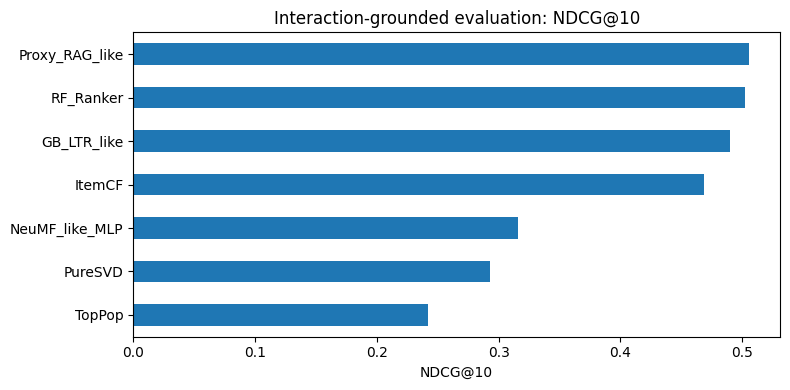

In [9]:
ax = baseline_results.sort_values('NDCG@K')['NDCG@K'].plot(kind='barh', figsize=(8,4), title='Interaction-grounded evaluation: NDCG@10')
ax.set_xlabel('NDCG@10')
plt.tight_layout()
plt.show()

## 5. Constraint Satisfaction Evaluation

We simulate user constraints such as:

- near the port
- near the university
- near the city center
- quiet area
- near main roads
- near public transport

For each query we evaluate whether the recommended top-3 neighborhoods satisfy the stated constraint.

In [10]:
CONSTRAINTS = {
    'near_port': lambda df: df['dist_port'] <= df['dist_port'].quantile(0.30),
    'near_university': lambda df: df['dist_university'] <= df['dist_university'].quantile(0.30),
    'near_center': lambda df: df['dist_center'] <= df['dist_center'].quantile(0.30),
    'quiet_area': lambda df: df['quietness'] >= df['quietness'].quantile(0.70),
    'near_main_road': lambda df: df['dist_main_road'] <= df['dist_main_road'].quantile(0.30),
    'near_transport': lambda df: df['dist_transport'] <= df['dist_transport'].quantile(0.30),
}
constraint_masks = {name: set(neigh.loc[fn(neigh), 'neighborhood_id'].astype(int)) for name, fn in CONSTRAINTS.items()}

# Query set: each category appears with one random constraint.
constraint_queries = []
for c in cats.category_id:
    for cname in RNG.choice(list(CONSTRAINTS.keys()), size=2, replace=False):
        constraint_queries.append({'category_id': int(c), 'constraint': cname})
constraint_queries = pd.DataFrame(constraint_queries)
constraint_queries.head()

,category_id,constraint
0,0,near_center
1,0,near_transport
2,1,near_university
3,1,near_center
4,2,near_center


In [11]:
def rerank_by_constraint(candidate_list, constraint_name, k=3):
    sat = constraint_masks[constraint_name]
    return sorted(candidate_list, key=lambda n: (n not in sat, n))[:k]

def static_top3(proxy_top10, c, constraint_name):
    return proxy_top10[c][:3]

def constraint_aware_top3(proxy_top10, c, constraint_name):
    return rerank_by_constraint(proxy_top10[c], constraint_name, k=3)

def constraint_satisfaction_rate(recommender_fn):
    vals = []
    for _, q in constraint_queries.iterrows():
        recs = recommender_fn(proxy_top10, int(q.category_id), q.constraint)
        sat = constraint_masks[q.constraint]
        vals.append(np.mean([n in sat for n in recs]))
    return np.mean(vals)

csr_results = pd.DataFrame({
    'Model': ['Static proxy / fine-tuned-like', 'Constraint-aware RAG-like'],
    'CSR@3': [constraint_satisfaction_rate(static_top3), constraint_satisfaction_rate(constraint_aware_top3)]
})
csr_results

,Model,CSR@3
0,Static proxy / fine-tuned-like,0.472222
1,Constraint-aware RAG-like,0.706944


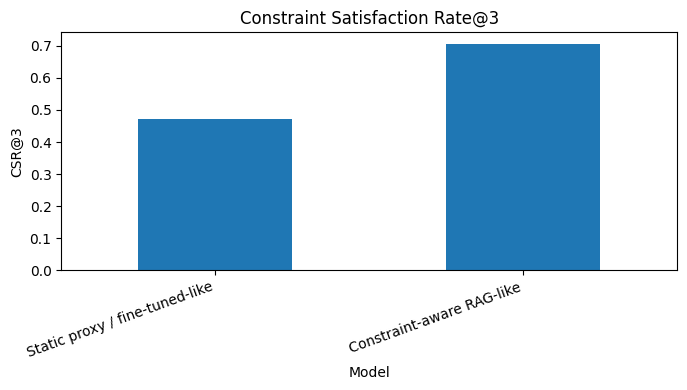

In [12]:
ax = csr_results.set_index('Model')['CSR@3'].plot(kind='bar', figsize=(7,4), title='Constraint Satisfaction Rate@3')
ax.set_ylabel('CSR@3')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## 6. Explanation Faithfulness by Feature Ablation

A SHAP-like explanation is only useful if the cited features materially affect the ranking. Here we use feature ablation:

1. Train a surrogate outcome/ranking model.
2. Identify important features via permutation importance.
3. Replace each important feature with its mean value.
4. Measure the ranking degradation.

This is a practical approximation to explanation faithfulness.

In [13]:
# Surrogate model for proxy membership in top-3.
pairs['proxy_top3_label'] = 0
for c, tops in proxy_top10.items():
    pairs.loc[(pairs.category_id == c) & (pairs.neighborhood_id.isin(tops[:3])), 'proxy_top3_label'] = 1

surrogate = RandomForestClassifier(n_estimators=250, random_state=11, class_weight='balanced', min_samples_leaf=3)
surrogate.fit(pairs[model_features], pairs['proxy_top3_label'])
perm = permutation_importance(surrogate, pairs[model_features], pairs['proxy_top3_label'], n_repeats=5, random_state=42, scoring='average_precision')
importance = pd.DataFrame({'feature': model_features, 'importance': perm.importances_mean}).sort_values('importance', ascending=False)
importance.head(10)

,feature,importance
11,population,0.115794
3,education_cat,0.070241
10,quietness_cat,0.066892
21,quietness,0.058933
20,dist_transport,0.055326
16,dist_center,0.051665
2,unemployment_cat,0.050243
1,income_cat,0.047683
0,population_cat,0.047289
6,dist_port_cat,0.045666


In [14]:
def model_rankings_from_surrogate(df, model, feature_cols, k=10):
    temp = df.copy()
    temp['score'] = model.predict_proba(temp[feature_cols])[:,1]
    return {int(c): list(g.sort_values('score', ascending=False).head(k)['neighborhood_id'].astype(int))
            for c, g in temp.groupby('category_id')}

base_rankings = model_rankings_from_surrogate(pairs, surrogate, model_features, k=10)
base_eval = evaluate_rankings(base_rankings, proxy_top10, k=10, name='base')

faith_rows = []
for feat in importance.head(8)['feature']:
    ablated = pairs.copy()
    ablated[feat] = ablated[feat].mean()
    abl_rankings = model_rankings_from_surrogate(ablated, surrogate, model_features, k=10)
    abl_eval = evaluate_rankings(abl_rankings, proxy_top10, k=10, name='ablated')
    faith_rows.append({
        'ablated_feature': feat,
        'NDCG_drop': float(base_eval['NDCG@K'].iloc[0] - abl_eval['NDCG@K'].iloc[0]),
        'HR_drop': float(base_eval['HR@K'].iloc[0] - abl_eval['HR@K'].iloc[0]),
    })
faithfulness = pd.DataFrame(faith_rows).sort_values('NDCG_drop', ascending=False)
faithfulness

,ablated_feature,NDCG_drop,HR_drop
2,quietness_cat,0.007923,0.0
6,unemployment_cat,0.005225,0.0
1,education_cat,0.004251,0.0
7,income_cat,0.002765,0.0
5,dist_center,0.001629,0.0
4,dist_transport,-0.000356,0.0
3,quietness,-0.000509,0.0
0,population,-0.000818,0.0


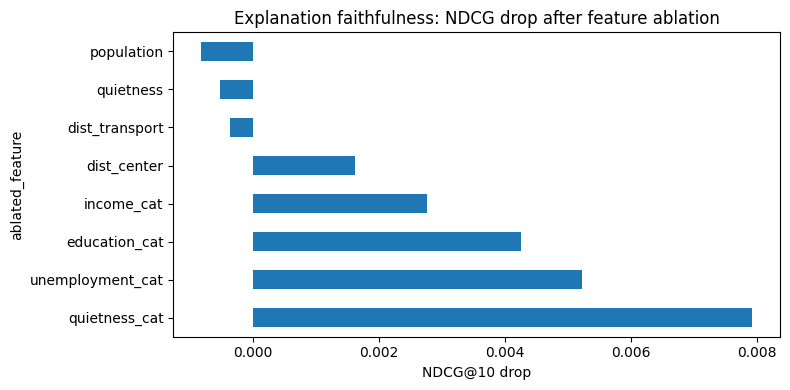

In [15]:
ax = faithfulness.set_index('ablated_feature')['NDCG_drop'].plot(kind='barh', figsize=(8,4), title='Explanation faithfulness: NDCG drop after feature ablation')
ax.set_xlabel('NDCG@10 drop')
plt.tight_layout()
plt.show()

## 7. Robustness and Sensitivity of Proxy Construction

We vary the rank-aggregation weights:

- Equal weights.
- Supervised-dominant.
- Unsupervised-dominant.
- Sparse-rating-dominant.
- 100 random weight combinations.

We measure Jaccard overlap with the reference proxy rankings.

In [16]:
def mean_jaccard(a: Dict[int,List[int]], b: Dict[int,List[int]], k=10):
    vals = []
    for c in a:
        A, B = set(a[c][:k]), set(b[c][:k])
        vals.append(len(A & B) / max(1, len(A | B)))
    return float(np.mean(vals))

weight_scenarios = {
    'equal': [1/3,1/3,1/3],
    'supervised_dominant': [0.6,0.2,0.2],
    'unsupervised_dominant': [0.2,0.6,0.2],
    'sparse_rating_dominant': [0.2,0.2,0.6],
}
robust_rows = []
for name, w in weight_scenarios.items():
    alt = rank_aggregate(pairs, score_cols, weights=w, k=10)
    robust_rows.append({'scenario': name, 'mean_jaccard_top10': mean_jaccard(proxy_top10, alt, k=10)})

# Random weight sensitivity
random_jaccards = []
for i in range(100):
    w = RNG.dirichlet([1,1,1])
    alt = rank_aggregate(pairs, score_cols, weights=w, k=10)
    random_jaccards.append(mean_jaccard(proxy_top10, alt, k=10))
robustness = pd.DataFrame(robust_rows)
robustness

,scenario,mean_jaccard_top10
0,equal,0.963636
1,supervised_dominant,0.756907
2,unsupervised_dominant,0.669586
3,sparse_rating_dominant,0.740240


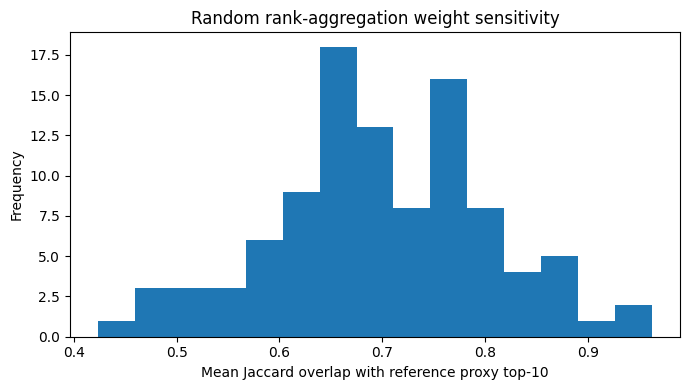

Random weights: mean Jaccard = 0.703 std = 0.106


In [ ]:
plt.figure(figsize=(7,4))
plt.hist(random_jaccards, bins=15)
plt.title('Random rank-aggregation weight sensitivity')
plt.xlabel('Mean Jaccard overlap with reference proxy top-10')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print('Random weights: mean Jaccard =', round(np.mean(random_jaccards), 3), 'std =', round(np.std(random_jaccards), 3))

## 8. Spatial Partitioning Robustness

We simulate alternative neighborhood granularities by clustering the 48 neighborhoods into coarser partitions:

- 16 regions
- 24 regions
- 32 regions
- 48 original neighborhoods

The goal is to check whether model conclusions are highly dependent on the chosen spatial partition.

In [18]:
def aggregate_to_partition(neigh, pairs, n_regions):
    if n_regions >= len(neigh):
        temp = pairs.copy()
        temp['region_id'] = temp['neighborhood_id']
        return temp
    km = KMeans(n_clusters=n_regions, random_state=100+n_regions, n_init=10).fit(neigh[['x','y']])
    region_map = pd.DataFrame({'neighborhood_id': neigh.neighborhood_id, 'region_id': km.labels_})
    temp = pairs.merge(region_map, on='neighborhood_id')
    # Aggregate scores per category-region, then rank regions.
    return temp

def partition_eval(n_regions):
    temp = aggregate_to_partition(neigh, pairs, n_regions)
    region_rankings = {}
    region_truth = {}
    for c, g in temp.groupby('category_id'):
        # predicted by aggregated proxy score from source components
        gg = g.groupby('region_id')[score_cols + ['score_outcome_model']].mean().reset_index()
        gg['proxy_mean'] = gg[score_cols].mean(axis=1)
        region_rankings[int(c)] = list(gg.sort_values('proxy_mean', ascending=False).head(10)['region_id'].astype(int))
        region_truth[int(c)] = list(gg.sort_values('score_outcome_model', ascending=False).head(10)['region_id'].astype(int))
    return evaluate_rankings(region_rankings, region_truth, k=min(10, n_regions), name=f'{n_regions}_regions')

partition_results = pd.concat([partition_eval(r) for r in [16,24,32,48]])
partition_results

,HR@K,Precision@K,Recall@K,NDCG@K,MAP@K,MRR@K
16_regions,1.0,0.8975,0.8975,0.994780,0.886573,0.995833
24_regions,1.0,0.8100,0.8100,0.970077,0.762146,0.967361
32_regions,1.0,0.7650,0.7650,0.963552,0.714748,0.971528
48_regions,1.0,0.6925,0.6925,0.928223,0.607821,0.929167


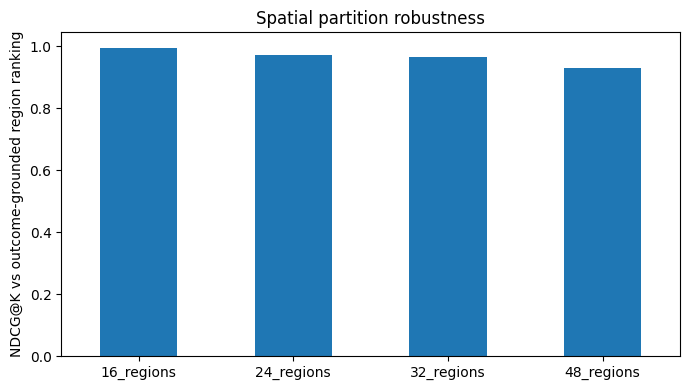

In [19]:
ax = partition_results['NDCG@K'].plot(kind='bar', figsize=(7,4), title='Spatial partition robustness')
ax.set_ylabel('NDCG@K vs outcome-grounded region ranking')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Ablation Study

We test whether individual components matter:

- Full proxy ensemble.
- No supervised component.
- No unsupervised component.
- No sparse-rating component.
- No accessibility features.
- No demographic features.

The evaluation target is the synthetic outcome-grounded ranking.

In [20]:
def ablation_prediction(use_scores, use_features=None):
    if use_features is None:
        return rank_aggregate(pairs, use_scores, weights=None, k=10)
    # Refit RF ranker using only selected features.
    m = RandomForestRegressor(n_estimators=150, random_state=23, min_samples_leaf=3)
    train_y = pairs['score_outcome_model']
    m.fit(pairs[use_features], train_y)
    temp = pairs.copy()
    temp['score'] = m.predict(temp[use_features])
    return {int(c): list(g.sort_values('score', ascending=False).head(10)['neighborhood_id'].astype(int))
            for c, g in temp.groupby('category_id')}

accessibility = ['dist_center','dist_port','dist_university','dist_main_road','dist_transport']
demographic = ['population','income','unemployment','education']
cat_feats = [f + '_cat' for f in feature_cols]

ablations = {
    'Full proxy ensemble': rank_aggregate(pairs, score_cols, weights=[0.33,0.34,0.33], k=10),
    'No supervised RF': rank_aggregate(pairs, ['score_kmeans','score_sparse_rating'], k=10),
    'No KMeans': rank_aggregate(pairs, ['score_rf','score_sparse_rating'], k=10),
    'No sparse-rating proxy': rank_aggregate(pairs, ['score_rf','score_kmeans'], k=10),
    'No accessibility features': ablation_prediction(score_cols, use_features=cat_feats + [f for f in feature_cols if f not in accessibility]),
    'No demographic features': ablation_prediction(score_cols, use_features=cat_feats + [f for f in feature_cols if f not in demographic]),
}

ablation_results = pd.concat([evaluate_rankings(pred, outcome_top10, k=10, name=name) for name, pred in ablations.items()])
ablation_results.sort_values('NDCG@K', ascending=False)

,HR@K,Precision@K,Recall@K,NDCG@K,MAP@K,MRR@K
No demographic features,1.0,0.877500,0.877500,0.994012,0.863292,1.000000
No accessibility features,1.0,0.883333,0.883333,0.992508,0.865165,1.000000
No KMeans,1.0,0.698333,0.698333,0.933124,0.609247,0.956944
Full proxy ensemble,1.0,0.637500,0.637500,0.905939,0.535078,0.903750
No sparse-rating proxy,1.0,0.582500,0.582500,0.854438,0.445559,0.850694
No supervised RF,1.0,0.545833,0.545833,0.848023,0.407764,0.863889


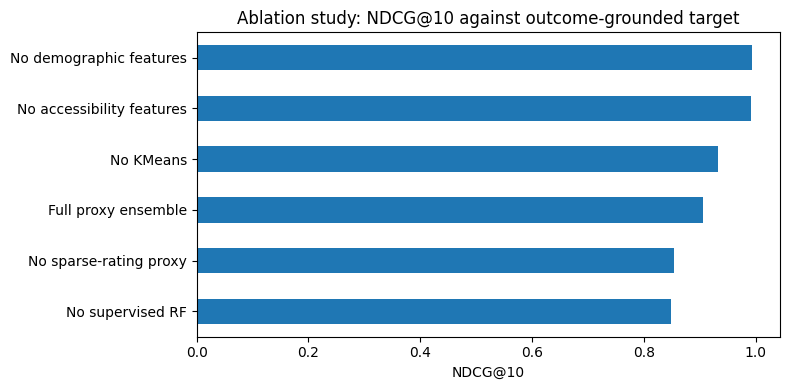

In [21]:
ax = ablation_results.sort_values('NDCG@K')['NDCG@K'].plot(kind='barh', figsize=(8,4), title='Ablation study: NDCG@10 against outcome-grounded target')
ax.set_xlabel('NDCG@10')
plt.tight_layout()
plt.show()

## 10. Summary Tables for Paper Reporting

The following tables are suitable starting points for paper revisions:

1. Baseline comparison table.
2. Constraint satisfaction table.
3. Explanation faithfulness table.
4. Proxy robustness table.
5. Spatial partition robustness table.
6. Ablation table.

In [22]:
summary_tables = {
    'baseline_results': baseline_results.sort_values('NDCG@K', ascending=False),
    'constraint_satisfaction': csr_results,
    'explanation_faithfulness': faithfulness,
    'proxy_weight_robustness': robustness,
    'spatial_partition_robustness': partition_results,
    'ablation_results': ablation_results.sort_values('NDCG@K', ascending=False),
}

for name, table in summary_tables.items():
    print('\n' + '='*80)
    print(name)
    display(table.round(4))


baseline_results


,HR@K,Precision@K,Recall@K,NDCG@K,MAP@K,MRR@K
Proxy_RAG_like,0.7500,0.0750,0.7500,0.5058,0.4280,0.4280
RF_Ranker,0.7583,0.0758,0.7583,0.5025,0.4228,0.4228
GB_LTR_like,0.7333,0.0733,0.7333,0.4902,0.4141,0.4141
ItemCF,0.7750,0.0775,0.7750,0.4686,0.3739,0.3739
NeuMF_like_MLP,0.5833,0.0583,0.5833,0.3159,0.2350,0.2350
PureSVD,0.5333,0.0533,0.5333,0.2931,0.2205,0.2205
TopPop,0.4833,0.0483,0.4833,0.2416,0.1703,0.1703



constraint_satisfaction


,Model,CSR@3
0,Static proxy / fine-tuned-like,0.4722
1,Constraint-aware RAG-like,0.7069



explanation_faithfulness


...

,scenario,mean_jaccard_top10
0,equal,0.9636
1,supervised_dominant,0.7569
2,unsupervised_dominant,0.6696
3,sparse_rating_dominant,0.7402



spatial_partition_robustness


,HR@K,Precision@K,Recall@K,NDCG@K,MAP@K,MRR@K
16_regions,1.0,0.8975,0.8975,0.9948,0.8866,0.9958
24_regions,1.0,0.8100,0.8100,0.9701,0.7621,0.9674
32_regions,1.0,0.7650,0.7650,0.9636,0.7147,0.9715
48_regions,1.0,0.6925,0.6925,0.9282,0.6078,0.9292



ablation_results


,HR@K,Precision@K,Recall@K,NDCG@K,MAP@K,MRR@K
No demographic features,1.0,0.8775,0.8775,0.9940,0.8633,1.0000
No accessibility features,1.0,0.8833,0.8833,0.9925,0.8652,1.0000
No KMeans,1.0,0.6983,0.6983,0.9331,0.6092,0.9569
Full proxy ensemble,1.0,0.6375,0.6375,0.9059,0.5351,0.9038
No sparse-rating proxy,1.0,0.5825,0.5825,0.8544,0.4456,0.8507
No supervised RF,1.0,0.5458,0.5458,0.8480,0.4078,0.8639


## 11. How to Translate This Notebook into the Paper

Suggested new subsections:

- **5.4 Interaction-Grounded Evaluation**: report HR@K/NDCG@K/MAP@K/MRR for TopPop, ItemCF, PureSVD, NeuMF-like, RF ranker, Gradient Boosting ranker, RAG, and fine-tuned model.
- **5.5 Constraint Satisfaction**: report CSR@3 for static vs constraint-aware approaches.
- **5.6 Explanation Faithfulness**: report feature ablation results and ranking degradation.
- **5.7 Robustness Analysis**: report proxy weight sensitivity and spatial partition sensitivity.
- **5.8 Ablation Study**: show which components contribute most.

The most important message to add is that the original LLM evaluation is an **emulation evaluation**, while the interaction/outcome-grounded experiments provide a stronger independent test.